In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load your dataset (replace 'your_dataset.csv' with your actual file)
df = pd.read_csv('data.csv')

In [107]:
# Step 1: Data Exploration

# Display the first few rows of the dataset
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [108]:
# Display information about the dataset (data types, non-null counts)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [109]:
# Summary statistics for numerical columns
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [110]:
# Check for missing values in each column
df.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

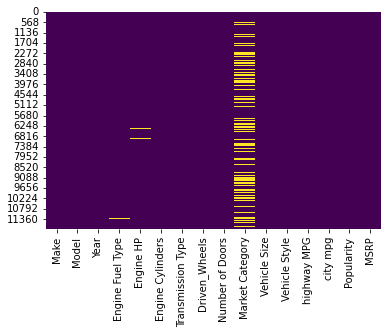

In [111]:
# Visualize missing values using a heatmap
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

In [112]:
# Step 2: Data Preprocessing

# Handle missing values (drop or impute)
df = df.dropna()

In [85]:
df.isnull().sum()

Make                 0
Model                0
Year                 0
Engine Fuel Type     0
Engine HP            0
Engine Cylinders     0
Transmission Type    0
Driven_Wheels        0
Number of Doors      0
Market Category      0
Vehicle Size         0
Vehicle Style        0
highway MPG          0
city mpg             0
Popularity           0
MSRP                 0
dtype: int64

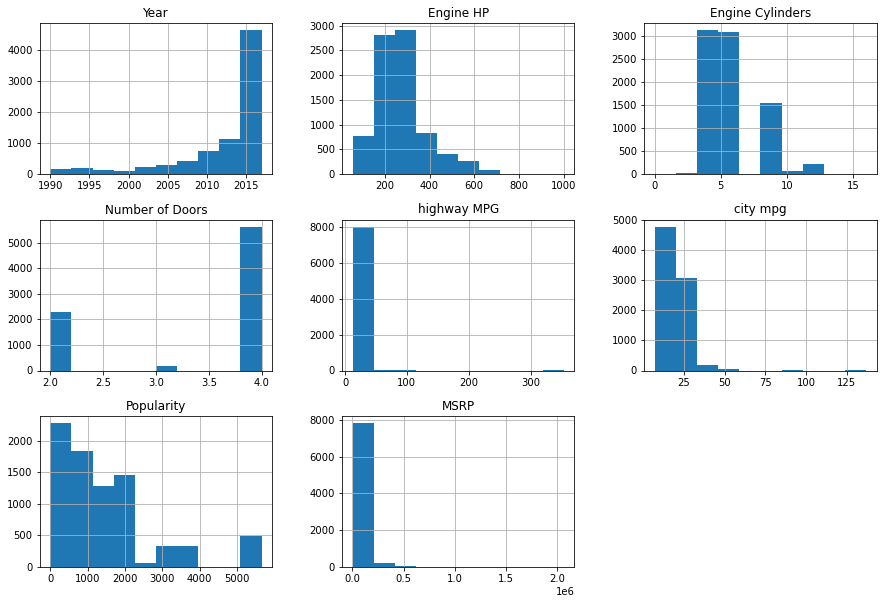

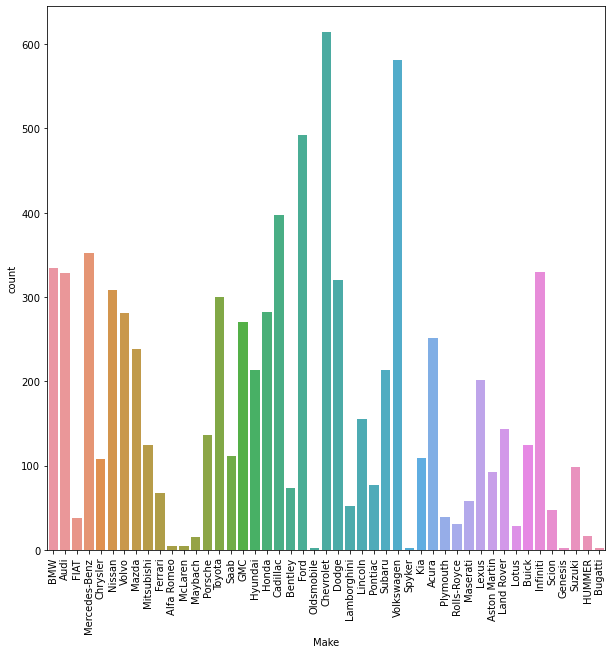

In [114]:
# Histograms for numerical features
df.hist(figsize=(15, 10))
plt.show()

# Countplot for categorical features

plt.figure(figsize=(10,10))
sns.countplot(x='Make', data=df)
plt.xticks(rotation=90)
plt.show()


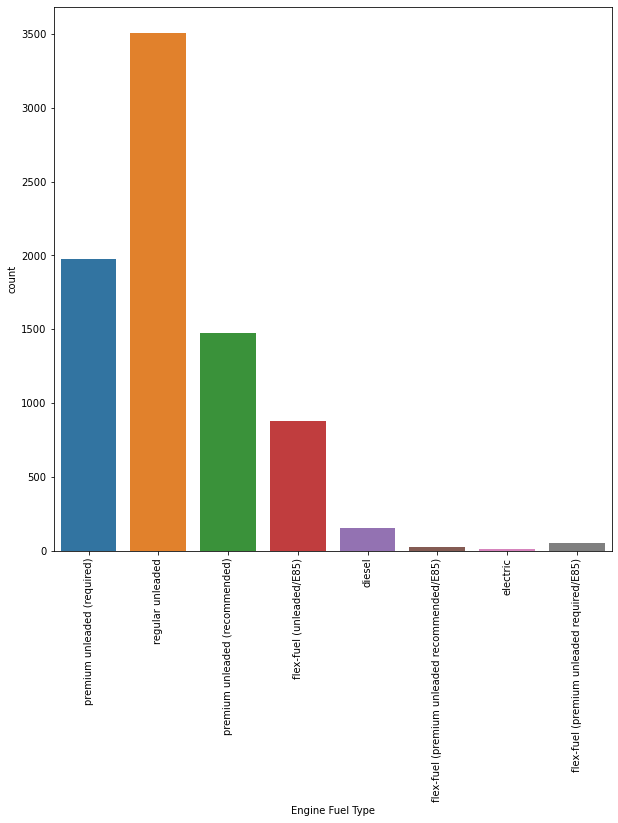

In [115]:
plt.figure(figsize=(10,10))
sns.countplot(x='Engine Fuel Type', data=df)
plt.xticks(rotation=90)
plt.show()

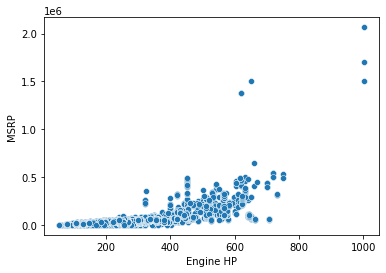

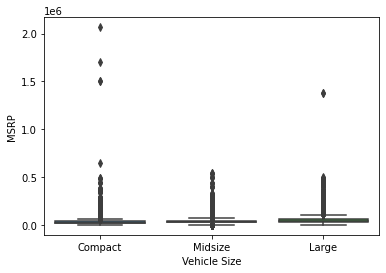

In [116]:
# Scatter plot for numerical features vs. target variable (e.g., 'price')
sns.scatterplot(x='Engine HP', y='MSRP', data=df)
plt.show()

# Box plot for categorical features vs. target variable
sns.boxplot(x='Vehicle Size', y='MSRP', data=df)
plt.show()

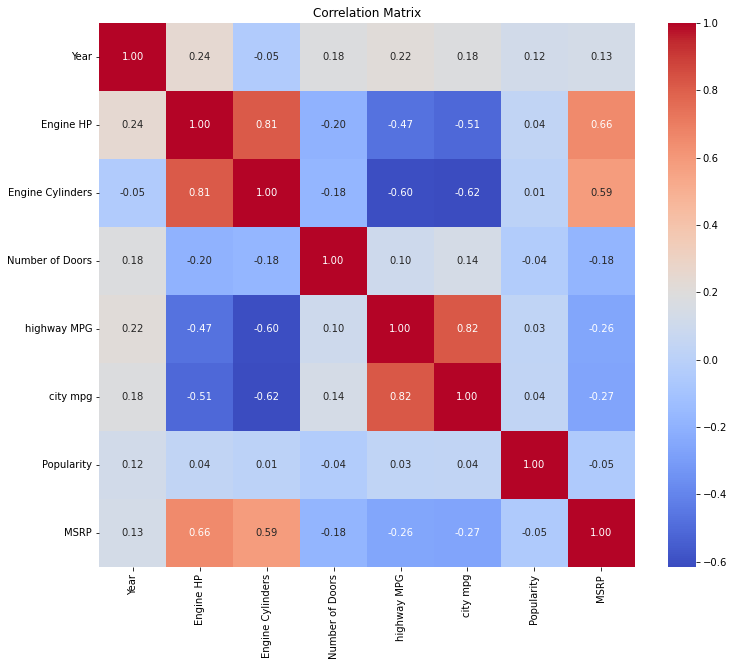

In [117]:
# Step 3: Feature Selection

# Correlation matrix
correlation_matrix = df.corr()

# Plotting heatmap for correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [118]:
# Identify features with strong correlation to the target variable (e.g., 'price')
target_correlation = correlation_matrix['MSRP'].sort_values(ascending=False)
print("Correlation with 'price':")
print(target_correlation)

Correlation with 'price':
MSRP                1.000000
Engine HP           0.656662
Engine Cylinders    0.589185
Year                0.133684
Popularity         -0.052477
Number of Doors    -0.184699
highway MPG        -0.257585
city mpg           -0.268003
Name: MSRP, dtype: float64


In [119]:
# Select features with correlation above a certain threshold (e.g., 0.5)
selected_features = target_correlation[abs(target_correlation) > 0.5].index.tolist()
print("Selected Features:")
print(selected_features)

Selected Features:
['MSRP', 'Engine HP', 'Engine Cylinders']


In [120]:
# Domain knowledge features
domain_features = ['Year', 'Engine Cylinders', 'highway MPG', 'city mpg']

In [121]:
# Combine selected features from correlation analysis and domain knowledge
final_features = selected_features + domain_features
print("Final Selected Features:")
print(final_features)

Final Selected Features:
['MSRP', 'Engine HP', 'Engine Cylinders', 'Year', 'Engine Cylinders', 'highway MPG', 'city mpg']


In [122]:
# Step 4: Train-Test Split

# Identify the target variable and features based on the selected features
target = 'MSRP'
features = df[final_features]

In [123]:
# Split the dataset into features and target variable
X = features
y = df[target]

In [124]:
# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [125]:
# Display the shapes of the resulting sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (6467, 7)
X_test shape: (1617, 7)
y_train shape: (6467,)
y_test shape: (1617,)


In [126]:
# Step 5: Model Building

# Initialize the linear regression model
model = LinearRegression()


In [127]:
# Step 6: Model Training

# Train the model on the training data
model.fit(X_train, y_train)

LinearRegression()

In [128]:
# Step 7: Model Evaluation (Prediction)

# Make predictions on the test set
y_pred = model.predict(X_test)


In [129]:
# Evaluate the model performance
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


In [130]:
# Display evaluation metrics
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R2):", r2)

Mean Squared Error (MSE): 6.753394489549965e-22
Mean Absolute Error (MAE): 1.2690460240415395e-11
R-squared (R2): 1.0


In [131]:
# Step 9: Interpret Results

# Display the coefficients of the linear regression model
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coefficients)

            Feature   Coefficient
0              MSRP  1.000000e+00
1         Engine HP -3.783538e-15
2  Engine Cylinders -7.524096e-14
3              Year  8.849630e-14
4  Engine Cylinders -7.524096e-14
5       highway MPG -4.446699e-14
6          city mpg -1.115763e-14


In [132]:
# Step 10: Conclusion

# Summarize findings and make recommendations if applicable
print("Model training and evaluation completed.")


Model training and evaluation completed.
